In [2]:
import os
import glob
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

OUT_DIR = "/home/akiva/FCNX-Ensembling/journal/LearningCubic_models"
os.makedirs(OUT_DIR, exist_ok=True)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if DEVICE.type == "cuda":
    torch.backends.cudnn.benchmark = True
    torch.backends.cuda.matmul.allow_tf32 = True

READOUTS = ("mf", "standard")
INV_SQRT_6 = 1.0 / np.sqrt(6)


def default_P_values(d):
    if d == 5:
        return sorted(set(
            np.unique(np.geomspace(d, d**3, 10).astype(int)).tolist()
            + [200, 500, 1000, 3000]
        ))
    if d == 10:
        return [50, 100, 200, 400, 700, 1000, 2000, 4000, 8000, 16000]
    return sorted(set(np.unique(np.geomspace(d, 4 * d**3, 12).astype(int)).tolist()))


def n_steps(P, steps_small=100_000, steps_large=300_000, large_P=500):
    return steps_large if P > large_P else steps_small


def f_target(x, eps):
    vx = x[:, 0]
    return vx + eps * INV_SQRT_6 * (vx**3 - 3 * vx)


def He3(vx):
    return (vx**3 - 3 * vx) * INV_SQRT_6


def gen(P, d, eps, device):
    x = torch.randn(P, d, device=device)
    return x, f_target(x, eps).unsqueeze(1)


class Net(nn.Module):
    """Two-layer erf net. readout='mf' -> /N; readout='standard' -> /sqrt(N)."""

    def __init__(self, d, N, readout="mf"):
        super().__init__()
        assert readout in READOUTS
        self.d = d
        self.N = N
        self.readout = readout
        self.inv_sqrt_d = 1.0 / np.sqrt(d)
        self.scale = 1.0 / N if readout == "mf" else 1.0 / np.sqrt(N)
        self.fc1 = nn.Linear(d, N)
        self.fc2 = nn.Linear(N, 1)

    def forward(self, x):
        h = torch.erf(self.fc1(x) * self.inv_sqrt_d)
        return self.fc2(h) * self.scale


def make_optimizer(model, base_lr=0.01):
    # Match function-space step: eta * readout_scale ~ base_lr
    if model.readout == "mf":
        lr = base_lr * model.N
    else:
        lr = base_lr * np.sqrt(model.N)
    return optim.SGD([
        {"params": model.fc1.parameters(), "lr": lr},
        {"params": model.fc2.parameters(), "lr": lr},
    ])


@torch.inference_mode()
def evaluate(model, x, y, he1, he3):
    f = model(x)
    inner_f_he1 = torch.mean(f * he1)
    inner_y_he3 = torch.mean(y * he3)
    f_res = f - inner_f_he1 * he1
    num = torch.mean(f_res * he3)
    mse = torch.mean((f - y) ** 2)
    ratio = (num / inner_y_he3).item() if inner_y_he3.abs() > 1e-8 else 0.0
    return mse.item(), ratio


def ckpt_path(out_dir, readout, d, N, eps, P, seed, steps):
    return os.path.join(
        out_dir,
        f"model_readout_{readout}_d{d}_N{N}_eps{eps}_P{P}_seed{seed}_steps{steps}.pt",
    )


def train_one(
    P,
    *,
    d,
    N,
    eps,
    readout,
    seed,
    device=DEVICE,
    batch_size=100,
    steps=None,
    base_lr=0.01,
    test_P=2000,
    out_dir=OUT_DIR,
    save=True,
):
    """Train a single (readout, P) run and optionally save a checkpoint."""
    if steps is None:
        steps = n_steps(P)

    torch.manual_seed(seed)
    if device.type == "cuda":
        torch.cuda.manual_seed_all(seed)

    model = Net(d, N, readout=readout).to(device)
    opt = make_optimizer(model, base_lr=base_lr)
    crit = nn.MSELoss()

    x_train, y_train = gen(P, d, eps, device)
    x_test, y_test = gen(test_P, d, eps, device)
    he1_test = x_test[:, 0].unsqueeze(1)
    he3_test = He3(x_test[:, 0]).unsqueeze(1)

    pb = min(batch_size, P)
    model.train()
    for _ in range(steps):
        idx = torch.randint(0, P, (pb,), device=device)
        opt.zero_grad(set_to_none=True)
        loss = crit(model(x_train[idx]), y_train[idx])
        loss.backward()
        opt.step()

    model.eval()
    test_mse, he3 = evaluate(model, x_test, y_test, he1_test, he3_test)
    state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
    ckpt = {
        "state_dict": state,
        "readout": readout,
        "P": int(P),
        "d": int(d),
        "N": int(N),
        "eps": float(eps),
        "seed": int(seed),
        "steps": int(steps),
        "test_mse": float(test_mse),
        "he3_learnability": float(he3),
    }
    path = None
    if save:
        path = ckpt_path(out_dir, readout, d, N, eps, P, seed, steps)
        torch.save(ckpt, path)
    return ckpt, path


def train_sweep(
    d,
    N=400,
    eps=0.5,
    seed0=42,
    P_values=None,
    readouts=READOUTS,
    device=DEVICE,
    out_dir=OUT_DIR,
    skip_existing=False,
):
    """Train MF and standard over a P grid. Returns results dict and models dict."""
    if P_values is None:
        P_values = default_P_values(d)
    P_values = list(P_values)

    results = {r: [] for r in readouts}
    models = {r: {} for r in readouts}

    print(f"device={device}, d={d}, N={N}, eps={eps}")
    print(f"P grid ({len(P_values)}): {P_values}")

    for readout in readouts:
        print(f"\n===== d={d} readout={readout} =====")
        for i, P in enumerate(P_values):
            steps = n_steps(P)
            run_seed = seed0 + i
            path = ckpt_path(out_dir, readout, d, N, eps, P, run_seed, steps)
            if skip_existing and os.path.exists(path):
                ckpt = torch.load(path, map_location="cpu", weights_only=False)
                print(
                    f"P={P:5d}  skip existing  MSE={ckpt['test_mse']:.4f}  "
                    f"He3={ckpt['he3_learnability']:.4f}"
                )
            else:
                ckpt, path = train_one(
                    P,
                    d=d,
                    N=N,
                    eps=eps,
                    readout=readout,
                    seed=run_seed,
                    device=device,
                    steps=steps,
                    out_dir=out_dir,
                )
                print(
                    f"P={P:5d}  steps={steps:6d}  MSE={ckpt['test_mse']:.4f}  "
                    f"He3={ckpt['he3_learnability']:.4f}"
                )
                print(f"  saved {path}")

            results[readout].append(
                (int(ckpt["P"]), float(ckpt["test_mse"]), float(ckpt["he3_learnability"]))
            )
            models[readout][int(ckpt["P"])] = ckpt["state_dict"]

    bundle = os.path.join(out_dir, f"all_state_dicts_d{d}_N{N}_eps{eps}.pt")
    torch.save({"models": models, "results": results, "P_values": P_values}, bundle)
    print(f"bundle: {bundle}")
    return results, models


def load_results(d, N=400, eps=0.5, out_dir=OUT_DIR, readouts=READOUTS):
    """Load per-P checkpoint metrics for a given d (individual files, last wins)."""
    loaded = {r: {} for r in readouts}  # P -> (mse, he3, path)
    models = {r: {} for r in readouts}
    for path in sorted(glob.glob(os.path.join(out_dir, "model_readout_*.pt"))):
        ckpt = torch.load(path, map_location="cpu", weights_only=False)
        if int(ckpt.get("d", -1)) != int(d):
            continue
        if int(ckpt.get("N", -1)) != int(N):
            continue
        if float(ckpt.get("eps", -1)) != float(eps):
            continue
        readout = ckpt["readout"]
        if readout not in loaded:
            continue
        P = int(ckpt["P"])
        loaded[readout][P] = (float(ckpt["test_mse"]), float(ckpt["he3_learnability"]), path)
        models[readout][P] = ckpt["state_dict"]

    results = {}
    for readout in readouts:
        rows = [(P, mse, he3) for P, (mse, he3, _) in sorted(loaded[readout].items())]
        results[readout] = rows
        print(f"loaded d={d} {readout}: {len(rows)} checkpoints")
        for P, mse, he3, path in [
            (P, *loaded[readout][P]) for P in sorted(loaded[readout])
        ]:
            print(f"  P={P:5d}  MSE={mse:.4f}  He3={he3:.4f}  <- {os.path.basename(path)}")
    return results, models


def plot_readout_comparison(results, d, N=400, eps=0.5, title=None):
    fig, ax = plt.subplots(1, 2, figsize=(12, 5))
    styles = {
        "mf": dict(marker="o", label="MF (1/N)"),
        "standard": dict(marker="s", label="Standard (1/√N)"),
    }
    for readout, style in styles.items():
        if not results.get(readout):
            continue
        Ps, mses, lrs = zip(*results[readout])
        ax[0].plot(Ps, mses, **style)
        ax[1].plot(Ps, lrs, **style)

    ax[0].set_xscale("log"); ax[0].set_yscale("log")
    ax[0].set_xlabel("P"); ax[0].set_ylabel("Test MSE")
    ax[0].grid(True, ls="--", c="0.7"); ax[0].legend()

    ax[1].set_xscale("log")
    ax[1].axhline(0, color="gray", ls=":")
    ax[1].set_xlabel("P"); ax[1].set_ylabel("He3 Learnability Ratio")
    ax[1].grid(True, ls="--", c="0.7"); ax[1].legend()

    fig.suptitle(title or f"Sample complexity (d={d}, N={N}, eps={eps})")
    plt.tight_layout()
    plt.show()

    if results.get("mf") and results.get("standard"):
        print(f"{'P':>6}  {'MSE_MF':>10}  {'MSE_std':>10}  {'He3_MF':>8}  {'He3_std':>8}")
        mf_map = {P: (mse, he3) for P, mse, he3 in results["mf"]}
        std_map = {P: (mse, he3) for P, mse, he3 in results["standard"]}
        for P in sorted(set(mf_map) & set(std_map)):
            mse_m, he3_m = mf_map[P]
            mse_s, he3_s = std_map[P]
            print(f"{P:6d}  {mse_m:10.4f}  {mse_s:10.4f}  {he3_m:8.4f}  {he3_s:8.4f}")


def plot_d_comparison(results_by_d, N=400, eps=0.5, readout="mf"):
    """Overlay curves for several d values; also plot vs P/d^3."""
    fig, ax = plt.subplots(1, 2, figsize=(12, 5))
    markers = {5: "o", 10: "s", 20: "^"}
    for d, results in sorted(results_by_d.items()):
        rows = results.get(readout, [])
        if not rows:
            continue
        Ps = np.array([r[0] for r in rows], dtype=float)
        mses = np.array([r[1] for r in rows], dtype=float)
        he3s = np.array([r[2] for r in rows], dtype=float)
        mk = markers.get(d, "o")
        ax[0].plot(Ps, he3s, marker=mk, label=f"d={d}")
        ax[1].plot(Ps / (d**3), he3s, marker=mk, label=f"d={d}")

    ax[0].set_xscale("log")
    ax[0].axhline(0, color="gray", ls=":")
    ax[0].set_xlabel("P")
    ax[0].set_ylabel("He3 Learnability")
    ax[0].grid(True, ls="--", c="0.7")
    ax[0].legend()
    ax[0].set_title(f"{readout}: He3 vs P")

    ax[1].set_xscale("log")
    ax[1].axhline(0, color="gray", ls=":")
    ax[1].set_xlabel(r"P / d^3")
    ax[1].set_ylabel("He3 Learnability")
    ax[1].grid(True, ls="--", c="0.7")
    ax[1].legend()
    ax[1].set_title(f"{readout}: He3 vs P/d^3 (collapse if ~d^3)")

    fig.suptitle(f"d comparison ({readout}, N={N}, eps={eps})")
    plt.tight_layout()
    plt.show()


print(f"helpers ready on {DEVICE}")


helpers ready on cuda


In [ ]:
# Train d=5 (skip checkpoints that already exist)
N, EPS, SEED0 = 400, 0.5, 42
results_d5, models_d5 = train_sweep(
    d=5, N=N, eps=EPS, seed0=SEED0, skip_existing=True
)


In [ ]:
# Load + plot d=5 from disk
results_d5, models_d5 = load_results(d=5, N=400, eps=0.5)
plot_readout_comparison(results_d5, d=5, N=400, eps=0.5)


device=cuda, d=10, N=400, eps=0.5
P grid (10): [50, 100, 200, 400, 700, 1000, 2000, 4000, 8000, 16000]

===== d=10 readout=mf =====
P=   50  steps=100000  MSE=0.3680  He3=-0.0624
  saved /home/akiva/FCNX-Ensembling/journal/LearningCubic_models/model_readout_mf_d10_N400_eps0.5_P50_seed42_steps100000.pt
P=  100  steps=100000  MSE=0.5845  He3=-0.0283
  saved /home/akiva/FCNX-Ensembling/journal/LearningCubic_models/model_readout_mf_d10_N400_eps0.5_P100_seed43_steps100000.pt
P=  200  steps=100000  MSE=0.5022  He3=-0.0631
  saved /home/akiva/FCNX-Ensembling/journal/LearningCubic_models/model_readout_mf_d10_N400_eps0.5_P200_seed44_steps100000.pt
P=  400  steps=100000  MSE=1.4717  He3=-0.0669
  saved /home/akiva/FCNX-Ensembling/journal/LearningCubic_models/model_readout_mf_d10_N400_eps0.5_P400_seed45_steps100000.pt
P=  700  steps=300000  MSE=0.2396  He3=0.1927
  saved /home/akiva/FCNX-Ensembling/journal/LearningCubic_models/model_readout_mf_d10_N400_eps0.5_P700_seed46_steps300000.pt
P= 1000  s

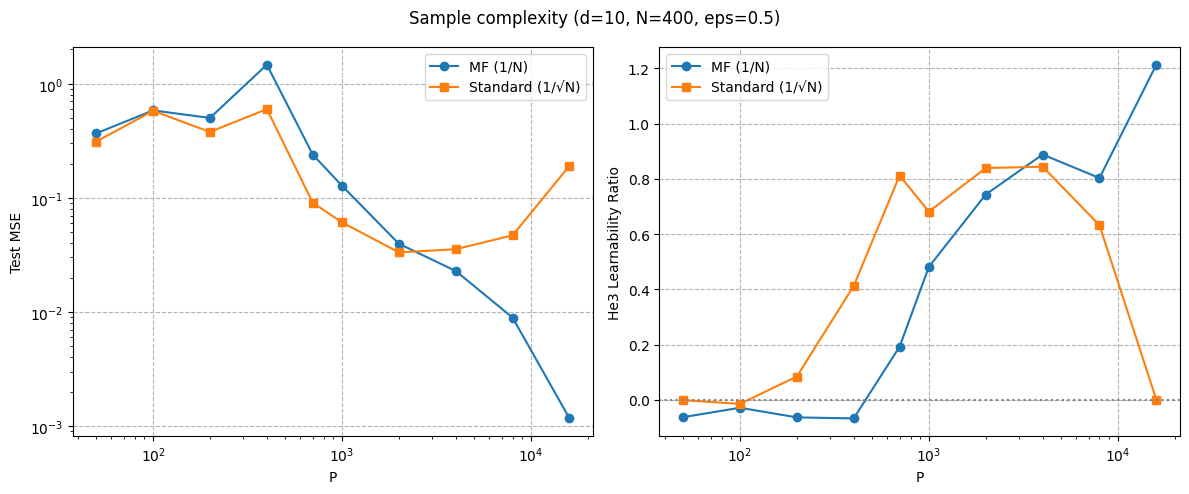

     P      MSE_MF     MSE_std    He3_MF   He3_std
    50      0.3680      0.3118   -0.0624   -0.0007
   100      0.5845      0.5795   -0.0283   -0.0143
   200      0.5022      0.3785   -0.0631    0.0848
   400      1.4717      0.6004   -0.0669    0.4124
   700      0.2396      0.0906    0.1927    0.8120
  1000      0.1276      0.0610    0.4814    0.6814
  2000      0.0396      0.0332    0.7432    0.8390
  4000      0.0228      0.0355    0.8880    0.8441
  8000      0.0089      0.0470    0.8030    0.6321
 16000      0.0012      0.1912    1.2130    0.0006

--- MF: d=5 vs d=10 ---


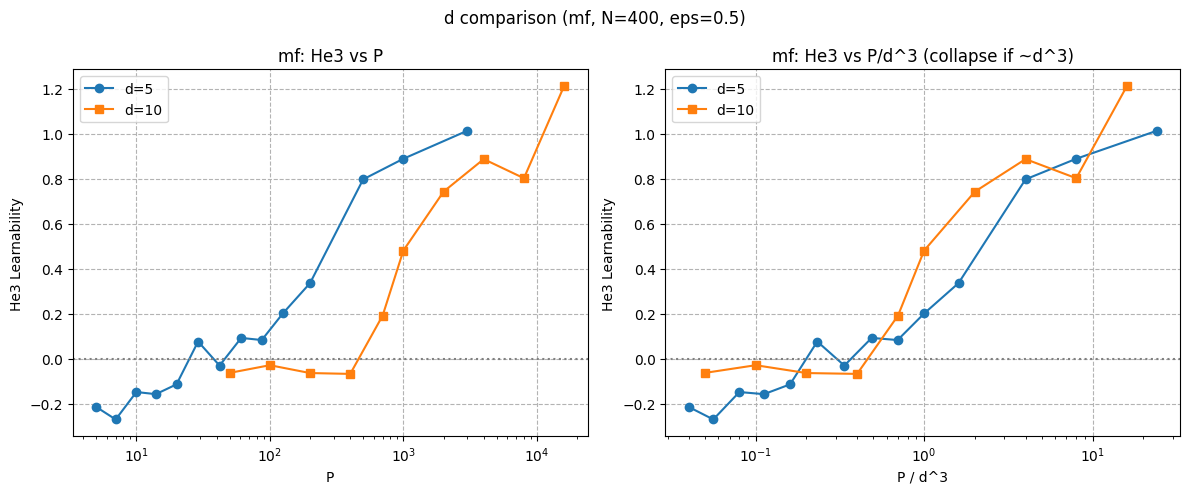


--- Standard: d=5 vs d=10 ---


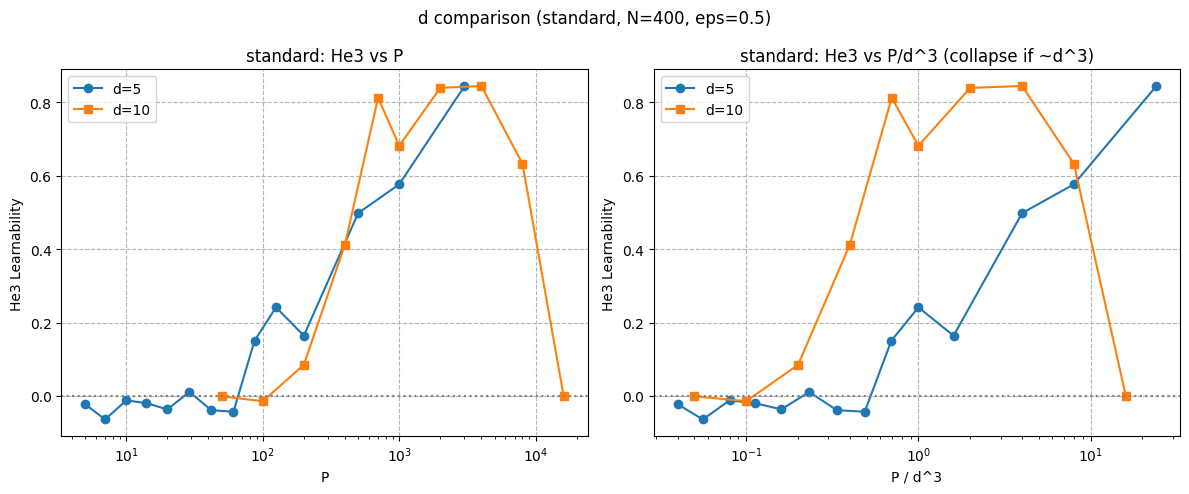

In [6]:
# Train d=10, store checkpoints, then compare d=5 vs d=10
N, EPS, SEED0 = 400, 0.5, 42
P_values_d10 = default_P_values(10)

results_d10, models_d10 = train_sweep(
    d=10,
    N=N,
    eps=EPS,
    seed0=SEED0,
    P_values=P_values_d10,
    skip_existing=True,
)

results_d5, _ = load_results(d=5, N=N, eps=EPS)
results_d10, _ = load_results(d=10, N=N, eps=EPS)

print("\n--- d=10 MF vs standard ---")
plot_readout_comparison(results_d10, d=10, N=N, eps=EPS)

results_by_d = {5: results_d5, 10: results_d10}
print("\n--- MF: d=5 vs d=10 ---")
plot_d_comparison(results_by_d, N=N, eps=EPS, readout="mf")
print("\n--- Standard: d=5 vs d=10 ---")
plot_d_comparison(results_by_d, N=N, eps=EPS, readout="standard")


loaded model_readout_mf_d10_N400_eps0.5_P8000_seed50_steps300000.pt  MSE=0.0089  He3=0.8030  steps=300000
step= 300001  train=0.0018  test=0.0016  He3=1.1931
step= 300500  train=0.0018  test=0.0017  He3=1.1943
step= 301000  train=0.0018  test=0.0016  He3=1.1931
step= 301500  train=0.0018  test=0.0016  He3=1.1947
step= 302000  train=0.0018  test=0.0017  He3=1.1931
step= 302500  train=0.0017  test=0.0016  He3=1.1939
step= 303000  train=0.0017  test=0.0016  He3=1.1949
step= 303500  train=0.0017  test=0.0016  He3=1.1944
step= 304000  train=0.0017  test=0.0016  He3=1.1944
step= 304500  train=0.0017  test=0.0016  He3=1.1940
step= 305000  train=0.0017  test=0.0016  He3=1.1913
step= 305500  train=0.0017  test=0.0016  He3=1.1944
step= 306000  train=0.0017  test=0.0016  He3=1.1949
step= 306500  train=0.0017  test=0.0016  He3=1.1916
step= 307000  train=0.0017  test=0.0016  He3=1.1940
step= 307500  train=0.0017  test=0.0016  He3=1.1950
step= 308000  train=0.0017  test=0.0016  He3=1.1946
step= 3085

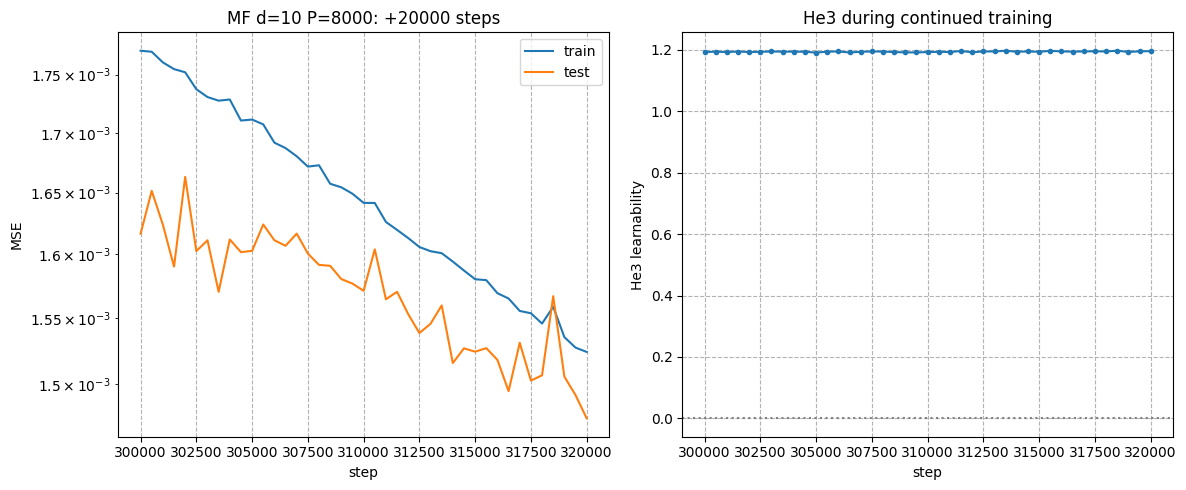

In [13]:
# Load d=10 P=400 MF checkpoint and train 20K more steps; log train/test MSE
d_diag, N_diag, eps_diag, P_diag = 10, 400, 0.5, 8000
seed_diag = 42 + default_P_values(d_diag).index(P_diag)
steps_extra = 20_000
log_every = 500
batch_size_diag = 100
readout = "mf"

steps0 = n_steps(P_diag)
path = ckpt_path(OUT_DIR, readout, d_diag, N_diag, eps_diag, P_diag, seed_diag, steps0)
assert os.path.exists(path), f"missing ckpt: {path}"

ckpt = torch.load(path, map_location=DEVICE, weights_only=False)
print(
    f"loaded {os.path.basename(path)}  "
    f"MSE={ckpt['test_mse']:.4f}  He3={ckpt['he3_learnability']:.4f}  steps={ckpt['steps']}"
)

# Fixed train/test sets (same recipe as train_sweep)
torch.manual_seed(seed_diag - 1)
if DEVICE.type == "cuda":
    torch.cuda.manual_seed_all(seed_diag - 1)
x_test, y_test = gen(2000, d_diag, eps_diag, DEVICE)
he1_test = x_test[:, 0].unsqueeze(1)
he3_test = He3(x_test[:, 0]).unsqueeze(1)

torch.manual_seed(seed_diag)
if DEVICE.type == "cuda":
    torch.cuda.manual_seed_all(seed_diag)
x_train, y_train = gen(P_diag, d_diag, eps_diag, DEVICE)

model = Net(d_diag, N_diag, readout=readout).to(DEVICE)
model.load_state_dict(ckpt["state_dict"])
opt = make_optimizer(model)
crit = nn.MSELoss()
pb = min(batch_size_diag, P_diag)
start_step = int(ckpt["steps"])

hist = {"step": [], "train_mse": [], "test_mse": [], "he3": []}
model.train()
for t in range(steps_extra):
    idx = torch.randint(0, P_diag, (pb,), device=DEVICE)
    opt.zero_grad(set_to_none=True)
    loss = crit(model(x_train[idx]), y_train[idx])
    loss.backward()
    opt.step()

    if t == 0 or (t + 1) % log_every == 0:
        model.eval()
        with torch.inference_mode():
            train_mse = crit(model(x_train), y_train).item()
            test_mse, he3 = evaluate(model, x_test, y_test, he1_test, he3_test)
        model.train()
        step = start_step + t + 1
        hist["step"].append(step)
        hist["train_mse"].append(train_mse)
        hist["test_mse"].append(test_mse)
        hist["he3"].append(he3)
        print(f"step={step:7d}  train={train_mse:.4f}  test={test_mse:.4f}  He3={he3:.4f}")

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].plot(hist["step"], hist["train_mse"], label="train")
ax[0].plot(hist["step"], hist["test_mse"], label="test")
ax[0].set_yscale("log")
ax[0].set_xlabel("step"); ax[0].set_ylabel("MSE")
ax[0].set_title(f"MF d={d_diag} P={P_diag}: +{steps_extra} steps")
ax[0].grid(True, ls="--", c="0.7"); ax[0].legend()

ax[1].plot(hist["step"], hist["he3"], marker="o", ms=3)
ax[1].axhline(0, color="gray", ls=":")
ax[1].set_xlabel("step"); ax[1].set_ylabel("He3 learnability")
ax[1].set_title("He3 during continued training")
ax[1].grid(True, ls="--", c="0.7")
plt.tight_layout(); plt.show()

# keep model in namespace for the next cell
model_P400_mf = model
x_test_P400, y_test_P400 = x_test, y_test


loaded model_readout_mf_d10_N400_eps0.5_P400_seed45_steps100000.pt
He3 learnability on plot set: -0.0184


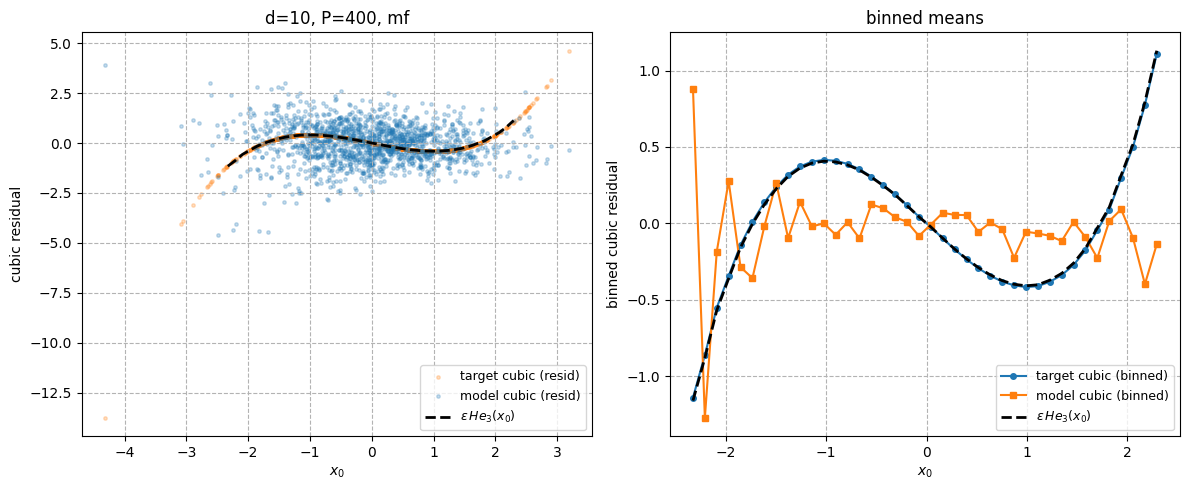


comparison: model_readout_mf_d10_N400_eps0.5_P2000_seed48_steps300000.pt  He3=0.7432
He3 learnability on plot set: 0.6226


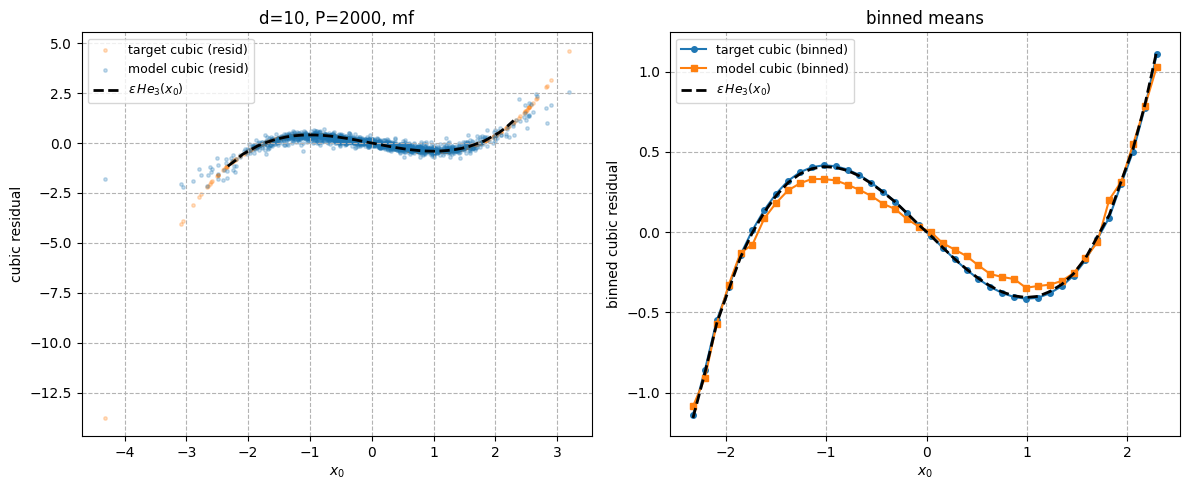

In [7]:
# Cubic component of f vs cubic component of y, both against x0
# Uses residualized outputs: g - <g, He1> He1  (same as the learnability metric)

def plot_cubic_vs_x0(
    model,
    d,
    eps,
    N=None,
    P_label=None,
    n_plot=4000,
    n_bins=40,
    device=DEVICE,
    seed=123,
):
    torch.manual_seed(seed)
    X = torch.randn(n_plot, d, device=device)
    x0 = X[:, 0]
    y = f_target(X, eps)
    he1 = x0
    he3 = He3(x0)

    model.eval()
    with torch.inference_mode():
        f = model(X).squeeze(-1)

    # residualize against He1 on this sample
    def residual_cubic(g):
        c1 = torch.mean(g * he1)
        return g - c1 * he1

    f_cub = residual_cubic(f)
    y_cub = residual_cubic(y)  # ≈ eps * He3 for this teacher

    x0_np = x0.detach().cpu().numpy()
    f_np = f_cub.detach().cpu().numpy()
    y_np = y_cub.detach().cpu().numpy()
    he3_np = (eps * he3).detach().cpu().numpy()

    # bin means vs x0 for a clean curve
    edges = np.linspace(np.percentile(x0_np, 1), np.percentile(x0_np, 99), n_bins + 1)
    centers = 0.5 * (edges[:-1] + edges[1:])
    dig = np.digitize(x0_np, edges) - 1

    def bin_mean(vals):
        out = np.full(n_bins, np.nan)
        for b in range(n_bins):
            m = dig == b
            if m.any():
                out[b] = vals[m].mean()
        return out

    fig, ax = plt.subplots(1, 2, figsize=(12, 5))

    # scatter (subsample)
    idx = np.random.default_rng(0).choice(n_plot, size=min(1500, n_plot), replace=False)
    ax[0].scatter(x0_np[idx], y_np[idx], s=6, alpha=0.25, label="target cubic (resid)", c="C1")
    ax[0].scatter(x0_np[idx], f_np[idx], s=6, alpha=0.25, label="model cubic (resid)", c="C0")
    ax[0].plot(centers, bin_mean(he3_np), "k--", lw=2, label=r"$\varepsilon\,He_3(x_0)$")
    ax[0].set_xlabel(r"$x_0$")
    ax[0].set_ylabel("cubic residual")
    ax[0].grid(True, ls="--", c="0.7")
    ax[0].legend(loc="best", fontsize=9)
    title = f"d={d}"
    if P_label is not None:
        title += f", P={P_label}"
    if getattr(model, "readout", None):
        title += f", {model.readout}"
    ax[0].set_title(title)

    ax[1].plot(centers, bin_mean(y_np), "o-", ms=4, label="target cubic (binned)")
    ax[1].plot(centers, bin_mean(f_np), "s-", ms=4, label="model cubic (binned)")
    ax[1].plot(centers, bin_mean(he3_np), "k--", lw=2, label=r"$\varepsilon\,He_3(x_0)$")
    ax[1].set_xlabel(r"$x_0$")
    ax[1].set_ylabel("binned cubic residual")
    ax[1].grid(True, ls="--", c="0.7")
    ax[1].legend(loc="best", fontsize=9)
    ax[1].set_title("binned means")

    # print He3 coeff for reference
    inner_y_he3 = torch.mean(y * he3)
    num = torch.mean(f_cub * he3)
    ratio = (num / inner_y_he3).item() if abs(inner_y_he3.item()) > 1e-8 else float("nan")
    print(f"He3 learnability on plot set: {ratio:.4f}")

    plt.tight_layout()
    plt.show()
    return fig


# Default: use continued P=400 MF model from previous cell if present; else load ckpt
d_c, N_c, eps_c, P_c = 10, 400, 0.5, 400
seed_c = 42 + default_P_values(d_c).index(P_c)
if "model_P400_mf" in dir() and model_P400_mf is not None:
    model_plot = model_P400_mf
    print("using model_P400_mf from previous cell")
else:
    path_c = ckpt_path(OUT_DIR, "mf", d_c, N_c, eps_c, P_c, seed_c, n_steps(P_c))
    ckpt_c = torch.load(path_c, map_location=DEVICE, weights_only=False)
    model_plot = Net(d_c, N_c, readout="mf").to(DEVICE)
    model_plot.load_state_dict(ckpt_c["state_dict"])
    print(f"loaded {os.path.basename(path_c)}")

plot_cubic_vs_x0(model_plot, d=d_c, eps=eps_c, P_label=P_c)

# Also show a well-trained MF point for comparison (P=2000) if available
P_good = 2000
path_good = ckpt_path(
    OUT_DIR, "mf", d_c, N_c, eps_c, P_good,
    42 + default_P_values(d_c).index(P_good), n_steps(P_good),
)
if os.path.exists(path_good):
    ckpt_g = torch.load(path_good, map_location=DEVICE, weights_only=False)
    model_good = Net(d_c, N_c, readout="mf").to(DEVICE)
    model_good.load_state_dict(ckpt_g["state_dict"])
    print(f"\ncomparison: {os.path.basename(path_good)}  "
          f"He3={ckpt_g['he3_learnability']:.4f}")
    plot_cubic_vs_x0(model_good, d=d_c, eps=eps_c, P_label=P_good)



===== d=5: load MF + arcsin KRR (5 draws) =====
loaded d=5 mf: 14 checkpoints
  P=    5  MSE=0.6819  He3=-0.2137  <- model_readout_mf_d5_N400_eps0.5_P5_seed42_steps100000.pt
  P=    7  MSE=3.0299  He3=-0.2694  <- model_readout_mf_d5_N400_eps0.5_P7_seed43_steps100000.pt
  P=   10  MSE=0.5592  He3=-0.1475  <- model_readout_mf_d5_N400_eps0.5_P10_seed44_steps100000.pt
  P=   14  MSE=0.4458  He3=-0.1570  <- model_readout_mf_d5_N400_eps0.5_P14_seed45_steps100000.pt
  P=   20  MSE=0.4243  He3=-0.1133  <- model_readout_mf_d5_N400_eps0.5_P20_seed46_steps100000.pt
  P=   29  MSE=0.3677  He3=0.0770  <- model_readout_mf_d5_N400_eps0.5_P29_seed47_steps100000.pt
  P=   42  MSE=0.5617  He3=-0.0299  <- model_readout_mf_d5_N400_eps0.5_P42_seed48_steps100000.pt
  P=   61  MSE=0.3353  He3=0.0930  <- model_readout_mf_d5_N400_eps0.5_P61_seed49_steps100000.pt
  P=   87  MSE=0.3099  He3=0.0836  <- model_readout_mf_d5_N400_eps0.5_P87_seed50_steps100000.pt
  P=  125  MSE=0.2694  He3=0.2016  <- model_readout_m

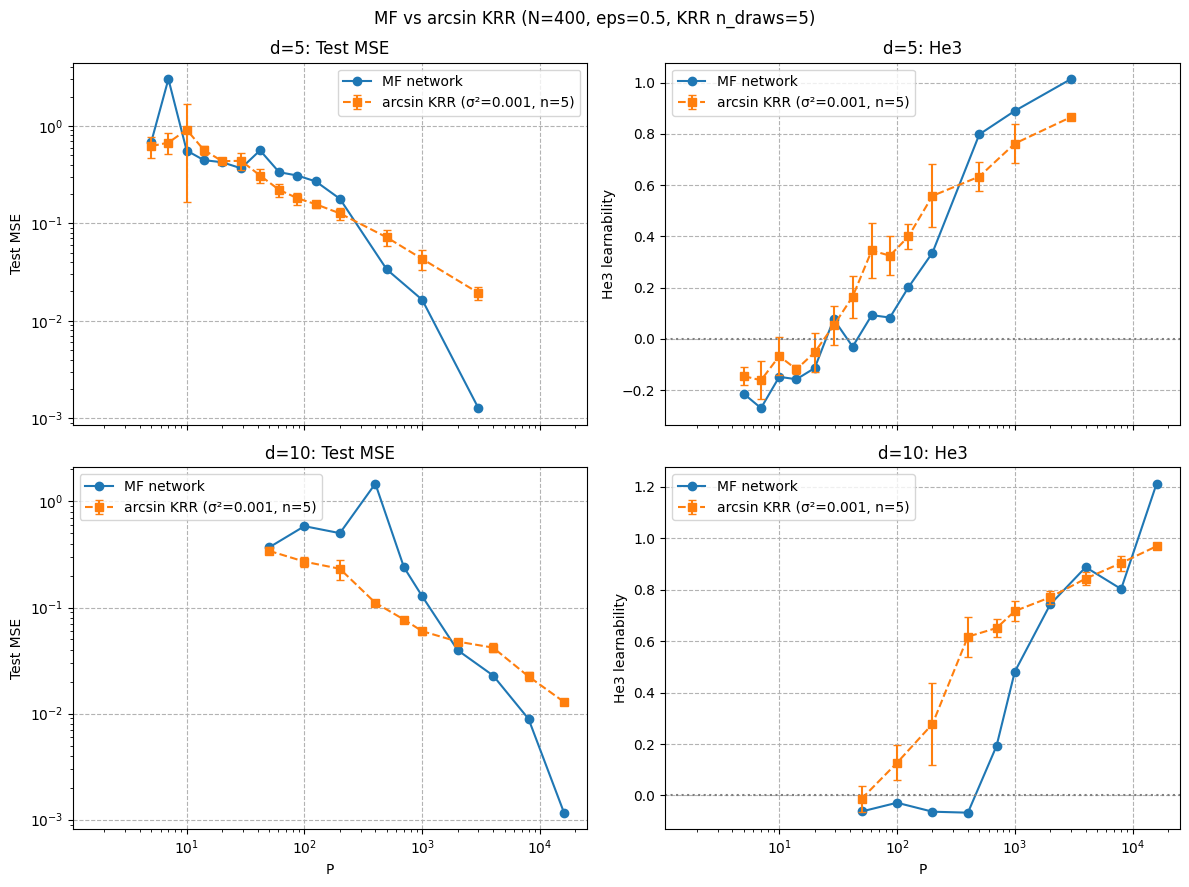

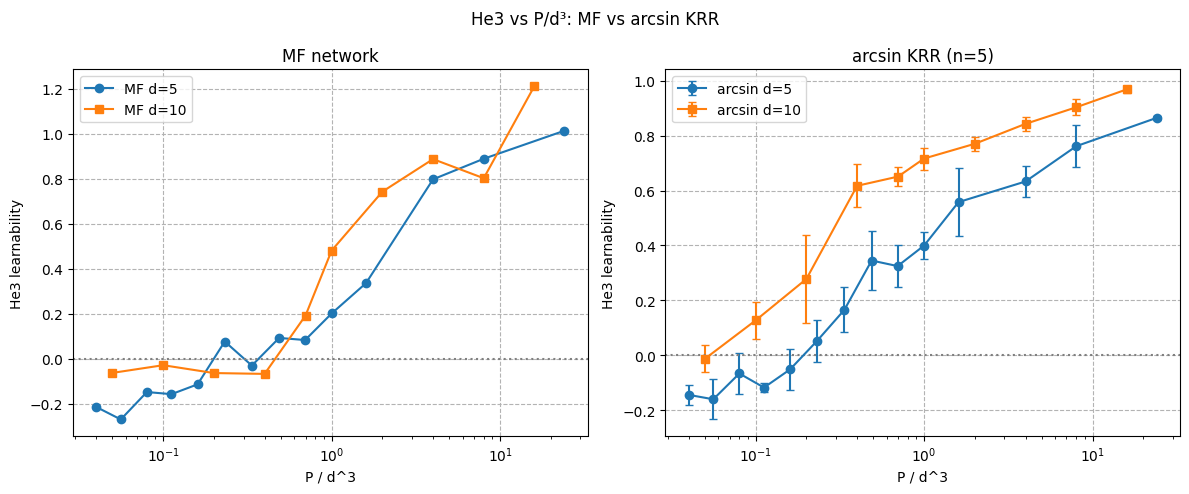


d=5  σ²=0.001  n_draws=5
     P      MSE_MF         MSE_arc    He3_MF         He3_arc
     5      0.6819  0.6211±0.1548   -0.2137  -0.1448±0.0353
     7      3.0299  0.6740±0.1646   -0.2694  -0.1609±0.0736
    10      0.5592  0.9138±0.7473   -0.1475  -0.0668±0.0747
    14      0.4458  0.5674±0.0586   -0.1570  -0.1182±0.0169
    20      0.4243  0.4351±0.0291   -0.1133  -0.0519±0.0751
    29      0.3677  0.4387±0.0897    0.0770  0.0529±0.0769
    42      0.5617  0.3100±0.0528   -0.0299  0.1652±0.0823
    61      0.3353  0.2209±0.0322    0.0930  0.3452±0.1075
    87      0.3099  0.1814±0.0260    0.0836  0.3249±0.0756
   125      0.2694  0.1572±0.0140    0.2016  0.3999±0.0476
   200      0.1788  0.1267±0.0185    0.3365  0.5582±0.1232
   500      0.0337  0.0719±0.0130    0.7981  0.6335±0.0576
  1000      0.0164  0.0432±0.0102    0.8895  0.7621±0.0758
  3000      0.0013  0.0193±0.0028    1.0137  0.8654±0.0085

d=10  σ²=0.001  n_draws=5
     P      MSE_MF         MSE_arc    He3_MF         He

In [16]:
# Compare MF runs to infinite-width arcsin-kernel ridge (project definition)
# K_uv = (2/π) arcsin( 2 (x_u·x_v)/d / (s_u s_v) ),  s_i = sqrt(1 + 2||x_i||^2/d)
# Same formula as milestones/fcn2_erf_hidden_kernel/plot_model_vs_preact_krr.py
# and lib/kappa_eff_solver.py
# Arcsin KRR: average over n_draws independent training-set draws.

def arcsin_kernel(X, X2=None):
    d_in = X.shape[1]
    if X2 is None:
        X2 = X
    gram = (X @ X2.T) / d_in
    scale_x = torch.sqrt(1.0 + 2.0 * torch.sum(X * X, dim=1) / d_in)
    scale_y = torch.sqrt(1.0 + 2.0 * torch.sum(X2 * X2, dim=1) / d_in)
    arg = 2.0 * gram / (scale_x[:, None] * scale_y[None, :])
    arg = torch.clamp(arg, -1.0 + 1e-6, 1.0 - 1e-6)
    return (2.0 / torch.pi) * torch.arcsin(arg)


def arcsin_krr_predict_from_train(X_train, y_train, X_eval, sigma2):
    K_tt = arcsin_kernel(X_train)
    p = K_tt.shape[0]
    eye = torch.eye(p, device=X_train.device, dtype=X_train.dtype)
    alpha = torch.linalg.solve(K_tt + sigma2 * eye, y_train.reshape(-1, 1)).squeeze(-1)
    K_et = arcsin_kernel(X_eval, X_train)
    return K_et @ alpha


def he3_of_predictor(f, y, he1, he3):
    """Same residual He3 learnability as evaluate()."""
    f = f.reshape(-1)
    y = y.reshape(-1)
    he1 = he1.reshape(-1)
    he3 = he3.reshape(-1)
    inner_f_he1 = torch.mean(f * he1)
    inner_y_he3 = torch.mean(y * he3)
    f_res = f - inner_f_he1 * he1
    num = torch.mean(f_res * he3)
    mse = torch.mean((f - y) ** 2)
    ratio = (num / inner_y_he3).item() if inner_y_he3.abs() > 1e-8 else float("nan")
    return mse.item(), ratio


def arcsin_krr_sweep(
    d,
    P_values,
    eps=0.5,
    sigma2=1e-4,
    seed0=42,
    n_draws=5,
    test_P=2000,
    device=DEVICE,
):
    """Arcsin KRR He3/MSE vs P, mean ± std over n_draws train-set seeds."""
    torch.manual_seed(seed0 - 1)
    if device.type == "cuda":
        torch.cuda.manual_seed_all(seed0 - 1)
    x_test, y_test = gen(test_P, d, eps, device)
    he1_test = x_test[:, 0]
    he3_test = He3(x_test[:, 0])
    y_flat = y_test.squeeze(-1)

    rows = []  # (P, mse_mean, mse_std, he3_mean, he3_std)
    for i, P in enumerate(P_values):
        mses, he3s = [], []
        for draw in range(n_draws):
            # distinct seed per (P index, draw)
            torch.manual_seed(seed0 + 1000 * draw + i)
            if device.type == "cuda":
                torch.cuda.manual_seed_all(seed0 + 1000 * draw + i)
            x_train, y_train = gen(P, d, eps, device)
            f_hat = arcsin_krr_predict_from_train(
                x_train, y_train.squeeze(-1), x_test, sigma2=sigma2
            )
            mse, he3 = he3_of_predictor(f_hat, y_flat, he1_test, he3_test)
            mses.append(mse)
            he3s.append(he3)
        mses = np.asarray(mses, float)
        he3s = np.asarray(he3s, float)
        rows.append(
            (
                int(P),
                float(mses.mean()),
                float(mses.std(ddof=0)),
                float(he3s.mean()),
                float(he3s.std(ddof=0)),
            )
        )
        print(
            f"arcsin KRR  d={d}  P={P:5d}  "
            f"MSE={mses.mean():.4f}±{mses.std(ddof=0):.4f}  "
            f"He3={he3s.mean():.4f}±{he3s.std(ddof=0):.4f}  (n={n_draws})"
        )
    return rows


# --- run comparison for d=5 and d=10 ---
N_cmp, EPS_cmp, SEED0_cmp = 400, 0.5, 42
SIGMA2 = 1e-3
N_DRAWS = 5

results_mf_by_d = {}
results_arcsin_by_d = {}

for d_cmp in (5, 10):
    print(f"\n===== d={d_cmp}: load MF + arcsin KRR ({N_DRAWS} draws) =====")
    mf_res, _ = load_results(d=d_cmp, N=N_cmp, eps=EPS_cmp)
    results_mf_by_d[d_cmp] = mf_res["mf"]
    P_list = [P for P, _, _ in mf_res["mf"]]
    if not P_list:
        P_list = default_P_values(d_cmp)
    results_arcsin_by_d[d_cmp] = arcsin_krr_sweep(
        d_cmp,
        P_list,
        eps=EPS_cmp,
        sigma2=SIGMA2,
        seed0=SEED0_cmp,
        n_draws=N_DRAWS,
    )

# plots: one row per d
fig, axes = plt.subplots(2, 2, figsize=(12, 9), sharex="col")
for row, d_cmp in enumerate((5, 10)):
    mf = results_mf_by_d[d_cmp]
    arc = results_arcsin_by_d[d_cmp]
    if not mf or not arc:
        continue
    P_m, mse_m, he3_m = zip(*mf)
    P_a = [r[0] for r in arc]
    mse_a = [r[1] for r in arc]
    mse_as = [r[2] for r in arc]
    he3_a = [r[3] for r in arc]
    he3_as = [r[4] for r in arc]

    ax0, ax1 = axes[row]
    ax0.plot(P_m, mse_m, "o-", label="MF network")
    ax0.errorbar(
        P_a, mse_a, yerr=mse_as, fmt="s--", capsize=3,
        label=f"arcsin KRR (σ²={SIGMA2:g}, n={N_DRAWS})",
    )
    ax0.set_xscale("log"); ax0.set_yscale("log")
    ax0.set_ylabel("Test MSE")
    ax0.set_title(f"d={d_cmp}: Test MSE")
    ax0.grid(True, ls="--", c="0.7"); ax0.legend()

    ax1.plot(P_m, he3_m, "o-", label="MF network")
    ax1.errorbar(
        P_a, he3_a, yerr=he3_as, fmt="s--", capsize=3,
        label=f"arcsin KRR (σ²={SIGMA2:g}, n={N_DRAWS})",
    )
    ax1.axhline(0, color="gray", ls=":")
    ax1.set_xscale("log")
    ax1.set_ylabel("He3 learnability")
    ax1.set_title(f"d={d_cmp}: He3")
    ax1.grid(True, ls="--", c="0.7"); ax1.legend()

axes[-1, 0].set_xlabel("P")
axes[-1, 1].set_xlabel("P")
fig.suptitle(f"MF vs arcsin KRR (N={N_cmp}, eps={EPS_cmp}, KRR n_draws={N_DRAWS})")
plt.tight_layout()
plt.show()

# overlay both d on P/d^3 for He3
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
for d_cmp, fmt in ((5, "o-"), (10, "s-")):
    mf = results_mf_by_d[d_cmp]
    arc = results_arcsin_by_d[d_cmp]
    if not mf:
        continue
    P_m = np.array([r[0] for r in mf], float)
    he3_m = np.array([r[2] for r in mf], float)
    P_a = np.array([r[0] for r in arc], float)
    he3_a = np.array([r[3] for r in arc], float)
    he3_as = np.array([r[4] for r in arc], float)
    ax[0].plot(P_m / d_cmp**3, he3_m, fmt, label=f"MF d={d_cmp}")
    ax[1].errorbar(
        P_a / d_cmp**3, he3_a, yerr=he3_as, fmt=fmt, capsize=3, label=f"arcsin d={d_cmp}"
    )

for a, title in zip(ax, ("MF network", f"arcsin KRR (n={N_DRAWS})")):
    a.set_xscale("log")
    a.axhline(0, color="gray", ls=":")
    a.set_xlabel(r"P / d^3")
    a.set_ylabel("He3 learnability")
    a.set_title(title)
    a.grid(True, ls="--", c="0.7")
    a.legend()
fig.suptitle("He3 vs P/d³: MF vs arcsin KRR")
plt.tight_layout()
plt.show()

# tables
for d_cmp in (5, 10):
    mf_map = {P: (mse, he3) for P, mse, he3 in results_mf_by_d[d_cmp]}
    arc_map = {P: (mse, ms, he3, hs) for P, mse, ms, he3, hs in results_arcsin_by_d[d_cmp]}
    print(f"\nd={d_cmp}  σ²={SIGMA2:g}  n_draws={N_DRAWS}")
    print(
        f"{'P':>6}  {'MSE_MF':>10}  {'MSE_arc':>14}  {'He3_MF':>8}  {'He3_arc':>14}"
    )
    for P in sorted(set(mf_map) & set(arc_map)):
        mse_m, he3_m = mf_map[P]
        mse_a, mse_s, he3_a, he3_s = arc_map[P]
        print(
            f"{P:6d}  {mse_m:10.4f}  {mse_a:6.4f}±{mse_s:.4f}  "
            f"{he3_m:8.4f}  {he3_a:6.4f}±{he3_s:.4f}"
        )



===== arcsin KRR asymptotics d=5 =====
arcsin KRR  d=5  P=   50  MSE=0.2375±0.0664  He3=0.3567±0.0966  (n=5)
arcsin KRR  d=5  P=  100  MSE=0.1580±0.0238  He3=0.4696±0.1213  (n=5)
arcsin KRR  d=5  P=  200  MSE=0.1359±0.0169  He3=0.4395±0.0623  (n=5)
arcsin KRR  d=5  P=  400  MSE=0.0901±0.0248  He3=0.6728±0.0731  (n=5)
arcsin KRR  d=5  P=  700  MSE=0.0429±0.0047  He3=0.7134±0.0356  (n=5)
arcsin KRR  d=5  P= 1000  MSE=0.0384±0.0025  He3=0.7370±0.0339  (n=5)
arcsin KRR  d=5  P= 2000  MSE=0.0212±0.0021  He3=0.8248±0.0187  (n=5)
arcsin KRR  d=5  P= 4000  MSE=0.6646±0.5031  He3=0.8724±0.1294  (n=5)
arcsin KRR  d=5  P= 8000  MSE=0.0081±0.0008  He3=0.9028±0.0075  (n=5)
arcsin KRR  d=5  P=16000  MSE=0.0052±0.0004  He3=0.9381±0.0043  (n=5)
arcsin KRR  d=5  P=30000  MSE=0.0029±0.0004  He3=0.9609±0.0045  (n=5)

===== arcsin KRR asymptotics d=10 =====
arcsin KRR  d=10  P=   50  MSE=0.3475±0.0252  He3=-0.0077±0.0522  (n=5)
arcsin KRR  d=10  P=  100  MSE=0.2740±0.0277  He3=0.1379±0.0695  (n=5)
arcsin

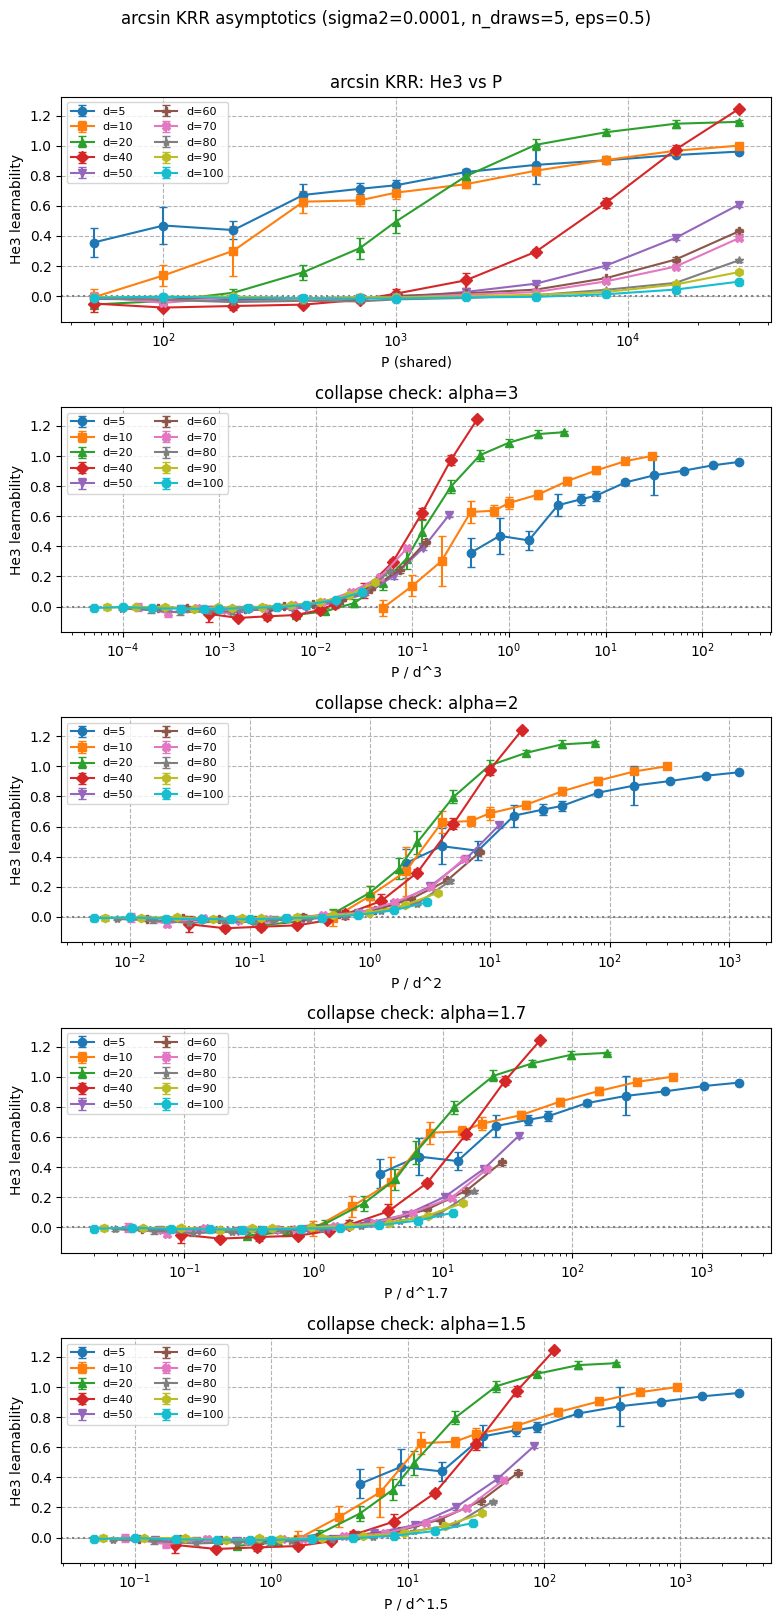


     P          He3_d5         He3_d10         He3_d20         He3_d40         He3_d50         He3_d60         He3_d70         He3_d80         He3_d90        He3_d100
    50   0.357±0.097   -0.008±0.052   -0.055±0.019   -0.049±0.053   -0.018±0.011   -0.011±0.014   -0.003±0.029   -0.014±0.010   -0.006±0.020   -0.010±0.015 
   100   0.470±0.121    0.138±0.070   -0.032±0.020   -0.076±0.017   -0.022±0.010   -0.007±0.011   -0.044±0.024   -0.024±0.020   -0.005±0.012   -0.003±0.015 
   200   0.439±0.062    0.302±0.165    0.023±0.026   -0.065±0.024   -0.025±0.011   -0.017±0.013   -0.007±0.015   -0.039±0.020   -0.002±0.014   -0.012±0.011 
   400   0.673±0.073    0.628±0.073    0.160±0.049   -0.056±0.013   -0.020±0.009   -0.018±0.006   -0.020±0.017   -0.031±0.008   -0.017±0.011   -0.014±0.003 
   700   0.713±0.036    0.637±0.035    0.319±0.071   -0.024±0.009   -0.013±0.010   -0.016±0.005   -0.012±0.013   -0.035±0.012   -0.006±0.011   -0.015±0.008 
  1000   0.737±0.034    0.688±0.042    0.496±0.

In [24]:
# Arcsin KRR asymptotics: same P grid across many d
# Uses arcsin_kernel / arcsin_krr_predict_from_train / he3_of_predictor from previous cell.

D_LIST = [5, 10, 20, 40, 50, 60, 70, 80, 90, 100]
# Shared P grid: covers ~d^3 for small d and probes mid-range for larger d
P_SHARED = [50, 100, 200, 400, 700, 1000, 2000, 4000, 8000, 16000, 30000]
EPS_ASY, SIGMA2_ASY, N_DRAWS_ASY, SEED0_ASY = 0.5, 1e-4, 5, 42

# Re-define helpers if this cell is run standalone after cell 0 only
if "arcsin_kernel" not in dir():
    def arcsin_kernel(X, X2=None):
        d_in = X.shape[1]
        if X2 is None:
            X2 = X
        gram = (X @ X2.T) / d_in
        scale_x = torch.sqrt(1.0 + 2.0 * torch.sum(X * X, dim=1) / d_in)
        scale_y = torch.sqrt(1.0 + 2.0 * torch.sum(X2 * X2, dim=1) / d_in)
        arg = 2.0 * gram / (scale_x[:, None] * scale_y[None, :])
        arg = torch.clamp(arg, -1.0 + 1e-6, 1.0 - 1e-6)
        return (2.0 / torch.pi) * torch.arcsin(arg)

    def arcsin_krr_predict_from_train(X_train, y_train, X_eval, sigma2):
        K_tt = arcsin_kernel(X_train)
        p = K_tt.shape[0]
        eye = torch.eye(p, device=X_train.device, dtype=X_train.dtype)
        alpha = torch.linalg.solve(K_tt + sigma2 * eye, y_train.reshape(-1, 1)).squeeze(-1)
        return arcsin_kernel(X_eval, X_train) @ alpha

    def he3_of_predictor(f, y, he1, he3):
        f, y, he1, he3 = f.reshape(-1), y.reshape(-1), he1.reshape(-1), he3.reshape(-1)
        inner_f_he1 = torch.mean(f * he1)
        inner_y_he3 = torch.mean(y * he3)
        f_res = f - inner_f_he1 * he1
        num = torch.mean(f_res * he3)
        mse = torch.mean((f - y) ** 2)
        ratio = (num / inner_y_he3).item() if inner_y_he3.abs() > 1e-8 else float("nan")
        return mse.item(), ratio

    def arcsin_krr_sweep(d, P_values, eps=0.5, sigma2=1e-4, seed0=42, n_draws=5, test_P=2000, device=DEVICE):
        torch.manual_seed(seed0 - 1)
        if device.type == "cuda":
            torch.cuda.manual_seed_all(seed0 - 1)
        x_test, y_test = gen(test_P, d, eps, device)
        he1_test, he3_test = x_test[:, 0], He3(x_test[:, 0])
        y_flat = y_test.squeeze(-1)
        rows = []
        for i, P in enumerate(P_values):
            mses, he3s = [], []
            for draw in range(n_draws):
                torch.manual_seed(seed0 + 1000 * draw + i)
                if device.type == "cuda":
                    torch.cuda.manual_seed_all(seed0 + 1000 * draw + i)
                x_train, y_train = gen(P, d, eps, device)
                f_hat = arcsin_krr_predict_from_train(
                    x_train, y_train.squeeze(-1), x_test, sigma2=sigma2
                )
                mse, he3 = he3_of_predictor(f_hat, y_flat, he1_test, he3_test)
                mses.append(mse); he3s.append(he3)
            mses, he3s = np.asarray(mses, float), np.asarray(he3s, float)
            rows.append((int(P), float(mses.mean()), float(mses.std(ddof=0)),
                         float(he3s.mean()), float(he3s.std(ddof=0))))
            print(f"arcsin  d={d:2d}  P={P:5d}  He3={he3s.mean():.4f}±{he3s.std(ddof=0):.4f}")
        return rows

# Keep previously computed d's if present; only compute missing ones
if "results_arcsin_asymp" not in dir() or not isinstance(results_arcsin_asymp, dict):
    results_arcsin_asymp = {}

for d_cmp in D_LIST:
    if d_cmp in results_arcsin_asymp and len(results_arcsin_asymp[d_cmp]) == len(P_SHARED):
        print(f"===== arcsin KRR asymptotics d={d_cmp} (cached) =====")
        continue
    print(f"\n===== arcsin KRR asymptotics d={d_cmp} =====")
    results_arcsin_asymp[d_cmp] = arcsin_krr_sweep(
        d_cmp,
        P_SHARED,
        eps=EPS_ASY,
        sigma2=SIGMA2_ASY,
        seed0=SEED0_ASY,
        n_draws=N_DRAWS_ASY,
    )

# Marker cycle for arbitrary D_LIST
_marker_cycle = ["o", "s", "^", "D", "v", "P", "X", "*", "h", "8"]
markers = {d: _marker_cycle[i % len(_marker_cycle)] for i, d in enumerate(D_LIST)}

# Vertical stack: raw P, then collapse checks for alpha = 3, 2, 1.7, 1.5
ALPHAS = [3.0, 2.0, 1.7, 1.5]
n_panels = 1 + len(ALPHAS)
fig, ax = plt.subplots(n_panels, 1, figsize=(8, 3.2 * n_panels), sharex=False)
if n_panels == 1:
    ax = [ax]

for d_cmp in D_LIST:
    rows = results_arcsin_asymp[d_cmp]
    P = np.array([r[0] for r in rows], float)
    he3 = np.array([r[3] for r in rows], float)
    he3s = np.array([r[4] for r in rows], float)
    mk = markers[d_cmp]
    ax[0].errorbar(P, he3, yerr=he3s, fmt=f"{mk}-", capsize=3, label=f"d={d_cmp}")
    for j, alpha in enumerate(ALPHAS):
        ax[1 + j].errorbar(
            P / (d_cmp ** alpha), he3, yerr=he3s,
            fmt=f"{mk}-", capsize=3, label=f"d={d_cmp}",
        )

ax[0].set_xscale("log")
ax[0].axhline(0, color="gray", ls=":")
ax[0].set_xlabel("P (shared)")
ax[0].set_ylabel("He3 learnability")
ax[0].set_title("arcsin KRR: He3 vs P")
ax[0].grid(True, ls="--", c="0.7")
ax[0].legend(ncol=2, fontsize=8)

for j, alpha in enumerate(ALPHAS):
    a = ax[1 + j]
    a.set_xscale("log")
    a.axhline(0, color="gray", ls=":")
    a.set_xlabel(f"P / d^{alpha:g}")
    a.set_ylabel("He3 learnability")
    a.set_title(f"collapse check: alpha={alpha:g}")
    a.grid(True, ls="--", c="0.7")
    a.legend(ncol=2, fontsize=8)

fig.suptitle(
    f"arcsin KRR asymptotics (sigma2={SIGMA2_ASY:g}, n_draws={N_DRAWS_ASY}, eps={EPS_ASY})",
    y=1.01,
)
plt.tight_layout()
plt.show()

# compact table at shared P
print(f"\n{'P':>6}", end="")
for d_cmp in D_LIST:
    print(f"  {'He3_d'+str(d_cmp):>14}", end="")
print()
for i, P in enumerate(P_SHARED):
    print(f"{P:6d}", end="")
    for d_cmp in D_LIST:
        _, _, _, he3, hs = results_arcsin_asymp[d_cmp][i]
        print(f"  {he3:6.3f}±{hs:<6.3f}", end="")
    print()


## d=20 full-batch Langevin (mean-field FCN2)

SGD in this notebook already learns the cubic at width `N=400`. This cell asks whether **full-batch Langevin** does too, using the same FCN2 / update as `milestones/fcn2_erf_hidden_kernel/train_fcn2_erf.py`:

- `d=20`, `N=400`, `chi=N` (full MF: \(\sigma_{W_0}^2=s_0/d\), \(\sigma_A^2=1/(N\chi)\))
- `P=4000` (d=20 arcsin KRR already has He3 ≈ 1 here)
- `eps=0.5`, `ens=1`, `s0=1`, `T=1` so \(T_{\mathrm{eff}}=T/\chi\)
- step: `lr = (base_lr / divisor) / P` on the **sum** MSE, plus weight decay and \(\mathcal{N}(0, 2\,\mathrm{lr}\,T_{\mathrm{eff}})\) noise
- schedule over 500k wall epochs: `lr0`, then `lr0/3`, then `lr0/5` in equal thirds (`base_lr=0.01`, matching this notebook's SGD function-space step)
- log train / test mean MSE (and He3) along the way

Langevin MF  d=20 N=400 P=4000 chi=400  T=1.0 T_eff=0.0025  base_lr=0.01  epochs=500000
  sigmaW0=0.05  sigmaA=6.25e-06  wd_W0=0.05  wd_A=400
  device=cuda
  epoch       0  lr=2.5000e-06  train=1.2114  test=1.2715  He3=-0.0023
  schedule: epoch 1  lr -> lr0/1
  epoch   20000  lr=2.5000e-06  train=0.0986  test=0.1359  He3=0.4395
  epoch   40000  lr=2.5000e-06  train=0.0835  test=0.1320  He3=0.4620
  epoch   60000  lr=2.5000e-06  train=0.0749  test=0.1325  He3=0.4639
  epoch   80000  lr=2.5000e-06  train=0.0694  test=0.1337  He3=0.4605
  epoch  100000  lr=2.5000e-06  train=0.0641  test=0.1350  He3=0.4639
  epoch  120000  lr=2.5000e-06  train=0.0602  test=0.1362  He3=0.4671
  epoch  140000  lr=2.5000e-06  train=0.0568  test=0.1387  He3=0.4647
  epoch  160000  lr=2.5000e-06  train=0.0547  test=0.1409  He3=0.4600
  schedule: epoch 166667  lr -> lr0/3
  epoch  180000  lr=8.3333e-07  train=0.0530  test=0.1417  He3=0.4603
  epoch  200000  lr=8.3333e-07  train=0.0525  test=0.1426  He3=0.4588
  

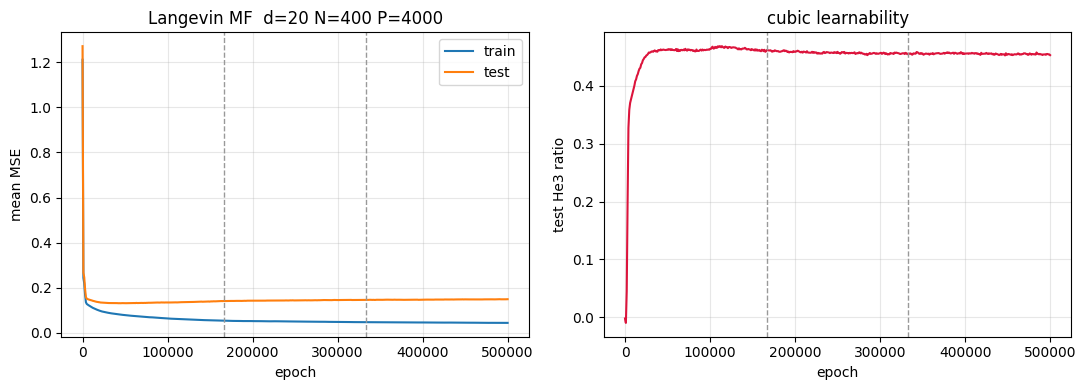

final  train=0.0445  test=0.1494  He3=0.4533


In [4]:
import sys
from pathlib import Path

sys.path.insert(0, "/home/akiva/FCNX-Ensembling/lib")
from FCN2Network import FCN2NetworkActivationGeneric

# Langevin update copied from train_fcn2_erf.py (full batch).
d_ld, N_ld, P_ld = 20, 400, 4000
eps_ld = 0.5
chi_ld = float(N_ld)  # full MF
s0_ld = 1.0
T_ld = 1.0
ens_ld = 1
base_lr_ld = 0.01
epochs_ld = 500_000
log_every_ld = 1_000
test_P_ld = 2000
seed_ld = 42

sigma_w0 = s0_ld / d_ld
sigma_a = 1.0 / (N_ld * chi_ld)
T_eff = T_ld / chi_ld
wd_W0 = (1.0 / sigma_w0) * T_eff
wd_A = N_ld * T_eff * chi_ld

tag_ld = (
    f"langevin_mf_d{d_ld}_N{N_ld}_P{P_ld}_chi{int(chi_ld)}"
    f"_lr{base_lr_ld}_T{T_ld}_eps{eps_ld}_seed{seed_ld}_ep{epochs_ld}"
)
hist_ld_path = os.path.join(OUT_DIR, f"{tag_ld}_history.npz")
ckpt_ld_path = os.path.join(OUT_DIR, f"{tag_ld}_model.pt")


def langevin_lr_divisor(epoch, epochs):
    """Equal wall thirds: lr0, lr0/3, lr0/5."""
    if epoch <= epochs // 3:
        return 1.0
    if epoch <= (2 * epochs) // 3:
        return 3.0
    return 5.0


def mean_mse(model, x, y):
    f = model(x)
    return torch.mean((f - y) ** 2).item()


def he3_ratio(model, x, y):
    f = model(x)
    he1 = x[:, :1]
    he3 = He3(x[:, 0]).unsqueeze(1)
    inner_f_he1 = torch.mean(f * he1)
    inner_y_he3 = torch.mean(y * he3)
    f_res = f - inner_f_he1 * he1
    num = torch.mean(f_res * he3)
    if inner_y_he3.abs() <= 1e-8:
        return 0.0
    return (num / inner_y_he3).item()


if os.path.exists(hist_ld_path):
    hist_ld = dict(np.load(hist_ld_path))
    done = int(hist_ld["epoch"][-1]) >= epochs_ld
    print(f"loaded {hist_ld_path}  last_epoch={int(hist_ld['epoch'][-1])}" + (" (complete)" if done else " (incomplete; retraining)"))
else:
    done = False

if not done:
    torch.manual_seed(seed_ld)
    if DEVICE.type == "cuda":
        torch.cuda.manual_seed_all(seed_ld)

    x_tr, y_tr = gen(P_ld, d_ld, eps_ld, DEVICE)
    x_te, y_te = gen(test_P_ld, d_ld, eps_ld, DEVICE)

    model_ld = FCN2NetworkActivationGeneric(
        d=d_ld,
        n1=N_ld,
        P=P_ld,
        ens=ens_ld,
        activation="erf",
        weight_initialization_variance=(sigma_w0, sigma_a),
        device=DEVICE,
    ).to(DEVICE)
    model_ld.train()

    epochs_log, train_mse, test_mse, he3_te, lr_log = [], [], [], [], []
    last_div = None
    print(
        f"Langevin MF  d={d_ld} N={N_ld} P={P_ld} chi={chi_ld:g}  "
        f"T={T_ld} T_eff={T_eff:.4g}  base_lr={base_lr_ld}  epochs={epochs_ld}"
    )
    print(f"  sigmaW0={sigma_w0:.4g}  sigmaA={sigma_a:.4g}  wd_W0={wd_W0:.4g}  wd_A={wd_A:.4g}")
    print(f"  device={DEVICE}")

    with torch.no_grad():
        epochs_log.append(0)
        train_mse.append(mean_mse(model_ld, x_tr, y_tr))
        test_mse.append(mean_mse(model_ld, x_te, y_te))
        he3_te.append(he3_ratio(model_ld, x_te, y_te))
        lr_log.append(base_lr_ld / P_ld)
        print(
            f"  epoch {0:7d}  lr={lr_log[-1]:.4e}  "
            f"train={train_mse[-1]:.4f}  test={test_mse[-1]:.4f}  He3={he3_te[-1]:.4f}"
        )

    for epoch in range(1, epochs_ld + 1):
        div = langevin_lr_divisor(epoch, epochs_ld)
        if div != last_div:
            print(f"  schedule: epoch {epoch}  lr -> lr0/{div:g}")
            last_div = div
        lr = (base_lr_ld / div) / P_ld
        noise_scale = np.sqrt(2.0 * lr * T_eff)

        output = model_ld(x_tr)
        loss = torch.sum((output - y_tr) ** 2)
        model_ld.zero_grad(set_to_none=True)
        loss.backward()
        with torch.no_grad():
            for name, param in model_ld.named_parameters():
                if param.grad is None:
                    continue
                wd = wd_W0 if name == "W0" else (wd_A if name == "A" else 0.0)
                param.add_(-lr * param.grad)
                if wd:
                    param.add_(-lr * wd * param.data)
                param.add_(torch.randn_like(param) * noise_scale)

        if epoch % log_every_ld == 0 or epoch == epochs_ld:
            with torch.no_grad():
                tr = mean_mse(model_ld, x_tr, y_tr)
                te = mean_mse(model_ld, x_te, y_te)
                h3 = he3_ratio(model_ld, x_te, y_te)
            epochs_log.append(epoch)
            train_mse.append(tr)
            test_mse.append(te)
            he3_te.append(h3)
            lr_log.append(lr)
            if epoch % (log_every_ld * 20) == 0 or epoch == epochs_ld:
                print(
                    f"  epoch {epoch:7d}  lr={lr:.4e}  "
                    f"train={tr:.4f}  test={te:.4f}  He3={h3:.4f}"
                )
            if epoch % (log_every_ld * 20) == 0:
                np.savez(
                    hist_ld_path,
                    epoch=np.asarray(epochs_log),
                    train_mse=np.asarray(train_mse),
                    test_mse=np.asarray(test_mse),
                    he3_test=np.asarray(he3_te),
                    lr=np.asarray(lr_log),
                )
                torch.save(model_ld.state_dict(), ckpt_ld_path)

    hist_ld = {
        "epoch": np.asarray(epochs_log),
        "train_mse": np.asarray(train_mse),
        "test_mse": np.asarray(test_mse),
        "he3_test": np.asarray(he3_te),
        "lr": np.asarray(lr_log),
    }
    np.savez(hist_ld_path, **hist_ld)
    torch.save(model_ld.state_dict(), ckpt_ld_path)
    print(f"saved {hist_ld_path}")
    print(f"saved {ckpt_ld_path}")

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(hist_ld["epoch"], hist_ld["train_mse"], label="train")
ax[0].plot(hist_ld["epoch"], hist_ld["test_mse"], label="test")
for frac, lab in ((1 / 3, r"lr$_0$/3"), (2 / 3, r"lr$_0$/5")):
    ax[0].axvline(frac * epochs_ld, color="0.6", ls="--", lw=1)
ax[0].set_xlabel("epoch")
ax[0].set_ylabel("mean MSE")
ax[0].set_title(f"Langevin MF  d={d_ld} N={N_ld} P={P_ld}")
ax[0].legend()
ax[0].grid(True, alpha=0.3)

ax[1].plot(hist_ld["epoch"], hist_ld["he3_test"], color="crimson")
for frac in (1 / 3, 2 / 3):
    ax[1].axvline(frac * epochs_ld, color="0.6", ls="--", lw=1)
ax[1].set_xlabel("epoch")
ax[1].set_ylabel("test He3 ratio")
ax[1].set_title("cubic learnability")
ax[1].grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

print(
    f"final  train={hist_ld['train_mse'][-1]:.4f}  "
    f"test={hist_ld['test_mse'][-1]:.4f}  He3={hist_ld['he3_test'][-1]:.4f}"
)


NNGP/GPR  σ²=0.5325 (kappa_eff, κ_bare=0.5)
test-set  Langevin  MSE=0.1543  He3=0.4391
test-set  NNGP/GPR  MSE=0.2452  He3=0.0143  (σ²=0.5325 kappa_eff)


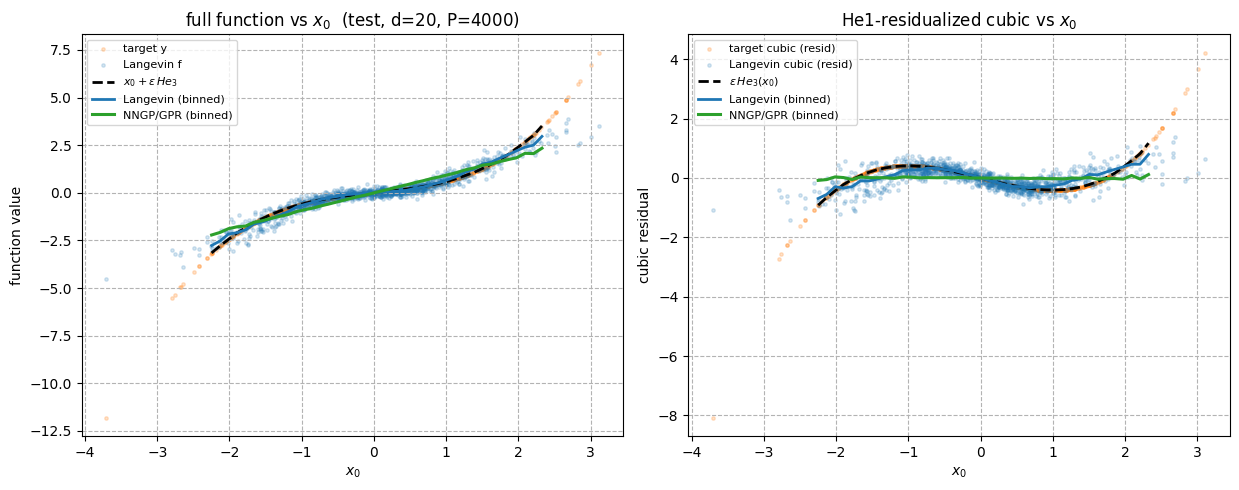

In [6]:
# Test-set view for the d=20 Langevin run: model vs infinite-width erf NNGP/GPR.
sys.path.insert(0, "/home/akiva/FCNX-Ensembling/lib")
from FCN2Network import FCN2NetworkActivationGeneric
from kappa_eff_solver import compute_kappa_eff

n_plot_ld = 4000
n_bins_ld = 40

if "model_ld" not in dir() or model_ld is None:
    model_ld = FCN2NetworkActivationGeneric(
        d=d_ld, n1=N_ld, P=P_ld, ens=ens_ld, activation="erf",
        weight_initialization_variance=(sigma_w0, sigma_a), device=DEVICE,
    ).to(DEVICE)
    model_ld.load_state_dict(torch.load(ckpt_ld_path, map_location=DEVICE, weights_only=True))
    print(f"loaded {ckpt_ld_path}")

# Reconstruct the Langevin training set (same seed) for GPR, then a held-out test plot set.
torch.manual_seed(seed_ld)
if DEVICE.type == "cuda":
    torch.cuda.manual_seed_all(seed_ld)
X_tr_gpr, y_tr_gpr = gen(P_ld, d_ld, eps_ld, DEVICE)
y_tr_gpr = y_tr_gpr.squeeze(-1)

torch.manual_seed(123)
if DEVICE.type == "cuda":
    torch.cuda.manual_seed_all(123)
X_plot = torch.randn(n_plot_ld, d_ld, device=DEVICE)
x0_plot = X_plot[:, 0]
y_plot = f_target(X_plot, eps_ld)
he1_plot = x0_plot
he3_plot = He3(x0_plot)

model_ld.eval()
with torch.inference_mode():
    f_plot = model_ld(X_plot).squeeze(-1)

# Infinite-width erf NNGP: K_uv = (2/π) arcsin( 2 (x_u·x_v)/d / (s_u s_v) )
# Ridge σ² = κ_eff (κ_bare = T/2), same convention as plot_model_vs_preact_krr.py
kappa_bare_ld = float(T_ld) / 2.0
try:
    sigma2_gpr = float(
        compute_kappa_eff(
            d=int(d_ld), P=int(P_ld), kappa_bare=kappa_bare_ld,
            n1=int(N_ld), chi=float(chi_ld), device=DEVICE, verbose=False,
        )
    )
    sigma2_gpr_label = "kappa_eff"
except Exception as exc:
    print(f"kappa_eff failed ({exc}); using kappa_bare={kappa_bare_ld}")
    sigma2_gpr = kappa_bare_ld
    sigma2_gpr_label = "kappa_bare"


def arcsin_kernel_ld(X, X2=None):
    d_in = X.shape[1]
    if X2 is None:
        X2 = X
    gram = (X @ X2.T) / d_in
    scale_x = torch.sqrt(1.0 + 2.0 * torch.sum(X * X, dim=1) / d_in)
    scale_y = torch.sqrt(1.0 + 2.0 * torch.sum(X2 * X2, dim=1) / d_in)
    arg = 2.0 * gram / (scale_x[:, None] * scale_y[None, :])
    arg = torch.clamp(arg, -1.0 + 1e-6, 1.0 - 1e-6)
    return (2.0 / torch.pi) * torch.arcsin(arg)


with torch.no_grad():
    K_tt = arcsin_kernel_ld(X_tr_gpr)
    eye = torch.eye(P_ld, device=DEVICE, dtype=X_tr_gpr.dtype)
    alpha_gpr = torch.linalg.solve(K_tt + sigma2_gpr * eye, y_tr_gpr)
    f_gpr = arcsin_kernel_ld(X_plot, X_tr_gpr) @ alpha_gpr
print(f"NNGP/GPR  σ²={sigma2_gpr:.4g} ({sigma2_gpr_label}, κ_bare={kappa_bare_ld:g})")


def residual_cubic(g, he1):
    return g - torch.mean(g * he1) * he1


def he3_learnability(f, x, y):
    he1 = x[:, 0]
    he3 = He3(x[:, 0])
    f_res = residual_cubic(f, he1)
    denom = torch.mean(y * he3)
    if denom.abs() <= 1e-8:
        return float("nan")
    return (torch.mean(f_res * he3) / denom).item()


f_cub = residual_cubic(f_plot, he1_plot)
gpr_cub = residual_cubic(f_gpr, he1_plot)
y_cub = residual_cubic(y_plot, he1_plot)

x0_np = x0_plot.detach().cpu().numpy()
f_np = f_plot.detach().cpu().numpy()
gpr_np = f_gpr.detach().cpu().numpy()
y_np = y_plot.detach().cpu().numpy()
f_cub_np = f_cub.detach().cpu().numpy()
gpr_cub_np = gpr_cub.detach().cpu().numpy()
y_cub_np = y_cub.detach().cpu().numpy()
teacher_full = (x0_plot + eps_ld * he3_plot).detach().cpu().numpy()
teacher_cub = (eps_ld * he3_plot).detach().cpu().numpy()

edges = np.linspace(np.percentile(x0_np, 1), np.percentile(x0_np, 99), n_bins_ld + 1)
centers = 0.5 * (edges[:-1] + edges[1:])
dig = np.digitize(x0_np, edges) - 1


def bin_mean(vals):
    out = np.full(n_bins_ld, np.nan)
    for b in range(n_bins_ld):
        m = dig == b
        if m.any():
            out[b] = vals[m].mean()
    return out


idx = np.random.default_rng(0).choice(n_plot_ld, size=min(1200, n_plot_ld), replace=False)
order = np.argsort(centers)

fig, ax = plt.subplots(1, 2, figsize=(12.5, 5))

ax[0].scatter(x0_np[idx], y_np[idx], s=6, alpha=0.22, c="C1", label="target y")
ax[0].scatter(x0_np[idx], f_np[idx], s=6, alpha=0.18, c="C0", label="Langevin f")
ax[0].plot(centers[order], bin_mean(teacher_full)[order], "k--", lw=2, label=r"$x_0 + \varepsilon\,He_3$")
ax[0].plot(centers[order], bin_mean(f_np)[order], color="C0", lw=2, label="Langevin (binned)")
ax[0].plot(centers[order], bin_mean(gpr_np)[order], color="C2", lw=2.2, label="NNGP/GPR (binned)")
ax[0].set_xlabel(r"$x_0$")
ax[0].set_ylabel("function value")
ax[0].set_title(f"full function vs $x_0$  (test, d={d_ld}, P={P_ld})")
ax[0].legend(fontsize=8)
ax[0].grid(True, ls="--", c="0.7")

ax[1].scatter(x0_np[idx], y_cub_np[idx], s=6, alpha=0.22, c="C1", label="target cubic (resid)")
ax[1].scatter(x0_np[idx], f_cub_np[idx], s=6, alpha=0.18, c="C0", label="Langevin cubic (resid)")
ax[1].plot(centers[order], bin_mean(teacher_cub)[order], "k--", lw=2, label=r"$\varepsilon\,He_3(x_0)$")
ax[1].plot(centers[order], bin_mean(f_cub_np)[order], color="C0", lw=2, label="Langevin (binned)")
ax[1].plot(centers[order], bin_mean(gpr_cub_np)[order], color="C2", lw=2.2, label="NNGP/GPR (binned)")
ax[1].set_xlabel(r"$x_0$")
ax[1].set_ylabel("cubic residual")
ax[1].set_title("He1-residualized cubic vs $x_0$")
ax[1].legend(fontsize=8)
ax[1].grid(True, ls="--", c="0.7")

he3_model = he3_learnability(f_plot, X_plot, y_plot)
he3_gpr = he3_learnability(f_gpr, X_plot, y_plot)
mse_model = torch.mean((f_plot - y_plot) ** 2).item()
mse_gpr = torch.mean((f_gpr - y_plot) ** 2).item()
print(
    f"test-set  Langevin  MSE={mse_model:.4f}  He3={he3_model:.4f}\n"
    f"test-set  NNGP/GPR  MSE={mse_gpr:.4f}  He3={he3_gpr:.4f}  "
    f"(σ²={sigma2_gpr:.4g} {sigma2_gpr_label})"
)

fig.tight_layout()
plt.show()


## Langevin P-sweep (50k epochs), $d\in\{5,10,20,30\}$

Same Langevin MF setup as the d=20 cell (`N=400`, `chi=N`, `T=1`, `base_lr=0.01`, schedule `lr0 → lr0/3 → lr0/5` in equal wall thirds, full batch), trained for **50k epochs** at

`P ∈ {50, 100, 500, 1000, 2000, 3000, 8000, 16000}`

and `d ∈ {5, 10, 20, 30}` to see where cubic learnability starts to rise. Overlay infinite-width erf NNGP/GPR (`σ²=κ_eff`) on the same train/test draws.

In [ ]:
# Langevin MF P-sweep over d={5,10,20,30}, P up to 16000, 50k epochs.
# Training lives in journal/run_langevin_d20_P_sweep.py (skip-if-complete).
import importlib.util

_sweep_path = "/home/akiva/FCNX-Ensembling/journal/run_langevin_d20_P_sweep.py"
_spec = importlib.util.spec_from_file_location("langevin_p_sweep", _sweep_path)
sweep = importlib.util.module_from_spec(_spec)
_spec.loader.exec_module(sweep)

sweep.main(dims=sweep.D_SWEEP_LD, P_list=sweep.P_SWEEP_LD, show=True)

